
x_train: (50000, 32, 32, 3) uint8
y_train: (50000, 1) uint8
x_test : (10000, 32, 32, 3) uint8
y_test : (10000, 1) uint8


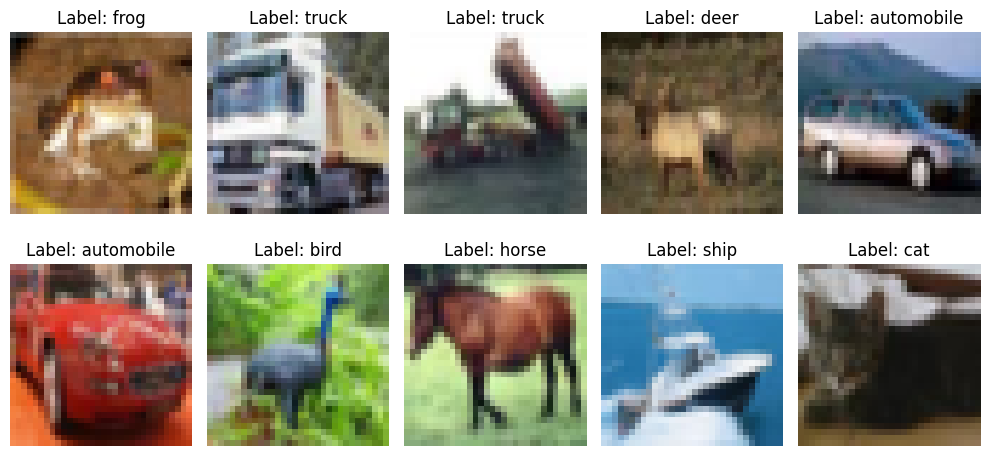

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

np.random.seed(42)
keras.backend.clear_session()

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

X_train = x_train.astype("float32") / 255.0
X_test  = x_test.astype("float32") / 255.0

y_train_ = y_train.squeeze()
y_test_  = y_test.squeeze()


print("x_train:", x_train.shape, x_train.dtype)  # (50000, 32, 32, 3)
print("y_train:", y_train.shape, y_train.dtype)  # (50000, 1)
print("x_test :", x_test.shape,  x_test.dtype)   # (10000, 32, 32, 3)
print("y_test :", y_test.shape,  y_test.dtype)   # (10000, 1)

class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]


fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_train[i])
    ax.set_title(f'Label: {class_names[y_train[i][0]]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [3]:
# l1_l2 regularization (elastic net) l1=1e-6, l2=1e-4 due to deep network

import os, datetime

optimizers = {"nadam": 0.0001, "adagrad": 0.003, "adam": 0.00003, "rmsprop": 0.0001, 
              "sgd": 0.001, "sgd_momentum": 0.0001, "sgd_nesterov": 0.0001}

keras.backend.clear_session()

base_dir = r"C:\Users\nisse\Skola\DIL700\Assignment4.1"

for opt_name, best_lr in optimizers.items():

    log_dir = os.path.join(
        base_dir, "logs", "cifar10_l1_l2", f"{opt_name}",
        f"lr_{best_lr}",
        datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    )
    tb = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=0)

    keras.backend.clear_session()
    model = keras.Sequential([
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Flatten(),
        *[keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal", 
                             kernel_regularizer=keras.regularizers.l1_l2(l1=1e-6, l2=1e-4)) for i in range(20)],
        keras.layers.Dense(10, activation="softmax")
    ])

    if opt_name == "nadam":
        optimizer = keras.optimizers.Nadam(learning_rate=float(best_lr))
    elif opt_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=float(best_lr))
    elif opt_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=float(best_lr))
    elif opt_name == "adagrad":
        optimizer = keras.optimizers.Adagrad(learning_rate=float(best_lr))
    elif opt_name == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=float(best_lr))
    elif opt_name == "sgd_momentum":
        optimizer = keras.optimizers.SGD(learning_rate=float(best_lr), momentum=0.9)
    elif opt_name == "sgd_nesterov":
        optimizer = keras.optimizers.SGD(learning_rate=float(best_lr), momentum=0.9, nesterov=True)
    else:
        raise ValueError(f"Unknown optimizer name: {opt_name}")

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

# glöm inte tb i callbacks sedan

    history = model.fit(
        X_train, y_train_,
        validation_split=0.1,
        epochs=50,
        batch_size=64,
        callbacks=[early_stop, tb],
    verbose=1
    )

    test_loss, test_acc = model.evaluate(X_test, y_test_, verbose=0)
    print("Test accuracy:", test_acc)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.3131 - loss: 2.3315 - val_accuracy: 0.3226 - val_loss: 2.2858
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3911 - loss: 2.1135 - val_accuracy: 0.3748 - val_loss: 2.2113
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4248 - loss: 2.0279 - val_accuracy: 0.4148 - val_loss: 2.0443
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4422 - loss: 1.9691 - val_accuracy: 0.4258 - val_loss: 2.0187
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4607 - loss: 1.9238 - val_accuracy: 0.4366 - val_loss: 2.0173
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4735 - loss: 1.8853 - val_accuracy: 0.4298 - val_loss: 2.0402
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4846 - loss: 1.8510 - val_accuracy: 0.4648 - val_loss: 1.9147
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4923 - loss: 1.8233 - val_acc

In [4]:
# dropout

import os, datetime


optimizers = {"nadam": 0.0001, "adagrad": 0.003, "adam": 0.00003, "rmsprop": 0.0001, 
              "sgd": 0.001, "sgd_momentum": 0.0001, "sgd_nesterov": 0.0001}

keras.backend.clear_session()

base_dir = r"C:\Users\nisse\Skola\DIL700\Assignment4.1"

for opt_name, best_lr in optimizers.items():

    log_dir = os.path.join(
        base_dir, "logs", "cifar10_dropout", f"{opt_name}",
        f"lr_{best_lr}",
        datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    )
    tb = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=0)

    keras.backend.clear_session()
    model = keras.Sequential([
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Flatten(),
        *[
        layer
        for _ in range(20)
        for layer in (
            keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
            keras.layers.Dropout(0.05), # very low dropout rate due to deep network
        )
    ],
        keras.layers.Dense(10, activation="softmax")
    ])

    if opt_name == "nadam":
        optimizer = keras.optimizers.Nadam(learning_rate=float(best_lr))
    elif opt_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=float(best_lr))
    elif opt_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=float(best_lr))
    elif opt_name == "adagrad":
        optimizer = keras.optimizers.Adagrad(learning_rate=float(best_lr))
    elif opt_name == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=float(best_lr))
    elif opt_name == "sgd_momentum":
        optimizer = keras.optimizers.SGD(learning_rate=float(best_lr), momentum=0.9)
    elif opt_name == "sgd_nesterov":
        optimizer = keras.optimizers.SGD(learning_rate=float(best_lr), momentum=0.9, nesterov=True)
    else:
        raise ValueError(f"Unknown optimizer name: {opt_name}")

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

# glöm inte tb i callbacks sedan

    history = model.fit(
        X_train, y_train_,
        validation_split=0.1,
        epochs=50,
        batch_size=64,
        callbacks=[early_stop, tb],
    verbose=1
    )

    test_loss, test_acc = model.evaluate(X_test, y_test_, verbose=0)
    print("Test accuracy:", test_acc)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 23ms/step - accuracy: 0.1178 - loss: 2.5706 - val_accuracy: 0.1892 - val_loss: 2.0841
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.1605 - loss: 2.1970 - val_accuracy: 0.2048 - val_loss: 2.0537
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.1914 - loss: 2.1052 - val_accuracy: 0.2606 - val_loss: 1.9419
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2206 - loss: 2.0270 - val_accuracy: 0.2756 - val_loss: 1.9232
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.2396 - loss: 1.9827 - val_accuracy: 0.2720 - val_loss: 1.9411
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.2652 - loss: 1.9435 - val_accuracy: 0.3026 - val_loss: 1.8509
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.2823 - loss: 1.9068 - val_accuracy: 0.3336 - val_loss: 1.7958
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3051 - loss: 1.8678 - v

In [5]:
# max-norm regularization

from tensorflow.keras.constraints import max_norm

optimizers = {"nadam": 0.0001, "adagrad": 0.003, "adam": 0.00003, "rmsprop": 0.0001, 
              "sgd": 0.001, "sgd_momentum": 0.0001, "sgd_nesterov": 0.0001}

keras.backend.clear_session()

base_dir = r"C:\Users\nisse\Skola\DIL700\Assignment4.1"

for opt_name, best_lr in optimizers.items():

    log_dir = os.path.join(
        base_dir, "logs", "cifar10_max_norm", f"{opt_name}",
        f"lr_{best_lr}",
        datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    )
    tb = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=0)

    keras.backend.clear_session()
    model = keras.Sequential([
        keras.layers.Input(shape=(32, 32, 3)),
        keras.layers.Flatten(),
        *[
        layer
        for _ in range(20)
        for layer in (
            keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal",
            kernel_constraint=max_norm(3.0)),
        )
    ],
        keras.layers.Dense(10, activation="softmax")
    ])

    if opt_name == "nadam":
        optimizer = keras.optimizers.Nadam(learning_rate=float(best_lr))
    elif opt_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=float(best_lr))
    elif opt_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=float(best_lr))
    elif opt_name == "adagrad":
        optimizer = keras.optimizers.Adagrad(learning_rate=float(best_lr))
    elif opt_name == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=float(best_lr))
    elif opt_name == "sgd_momentum":
        optimizer = keras.optimizers.SGD(learning_rate=float(best_lr), momentum=0.9)
    elif opt_name == "sgd_nesterov":
        optimizer = keras.optimizers.SGD(learning_rate=float(best_lr), momentum=0.9, nesterov=True)
    else:
        raise ValueError(f"Unknown optimizer name: {opt_name}")

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

# glöm inte tb i callbacks sedan

    history = model.fit(
        X_train, y_train_,
        validation_split=0.1,
        epochs=50,
        batch_size=64,
        callbacks=[early_stop, tb],
    verbose=1
    )

    test_loss, test_acc = model.evaluate(X_test, y_test_, verbose=0)
    print("Test accuracy:", test_acc)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 29ms/step - accuracy: 0.3073 - loss: 1.9122 - val_accuracy: 0.3380 - val_loss: 1.8460
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3946 - loss: 1.6823 - val_accuracy: 0.3910 - val_loss: 1.7029
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4257 - loss: 1.5990 - val_accuracy: 0.4118 - val_loss: 1.6856
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4478 - loss: 1.5426 - val_accuracy: 0.4234 - val_loss: 1.6057
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.4572 - loss: 1.5072 - val_accuracy: 0.4406 - val_loss: 1.5547
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.4705 - loss: 1.4723 - val_accuracy: 0.4370 - val_loss: 1.5676
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.4813 - loss: 1.4434 - val_accuracy: 0.4472 - val_loss: 1.5320
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.4909 - loss: 1.4208 - 

as expected some optimizers performed worse and some better. the best optimizer in excercise 3 was sgd_momentum which performed 48.73% in five minutes. the nadam optimizer in combination with dropout performed 50.46% validated accuracy in 9.6 minutes. Also, the nadam optimizer with the elastic net performed 49.14% accuracy in only 2 minutes which must be regarded as a major improvement.

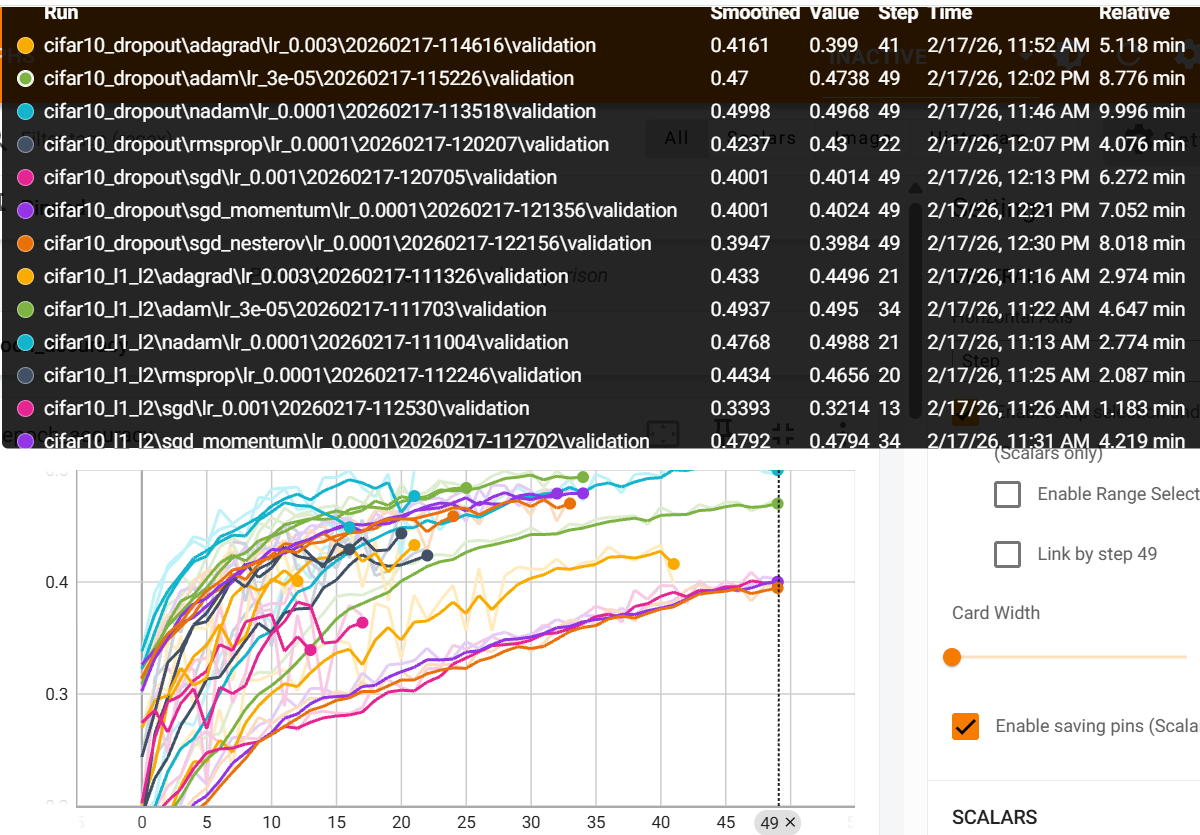